# Gráficos

In [50]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LogNorm
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader

sys.path.append("..")
from src.utils import (LIMPOS, COR_MUSICA, COR_MUSICA_CLARA, COR_FILME, COR_FILME_CLARA,
                       COR_CINZA, COR_TEXTO, FONTE_MUSICAS, FONTE_FILMES,
                       estilo, titulos, fonte, salvar)

estilo()

def br(x, casas=1):
    """Formata número no padrão brasileiro (vírgula decimal, ponto no milhar)."""
    return f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

musicas = pd.read_csv(LIMPOS / "musicas_limpas.csv")
musicas_unicas = musicas.drop_duplicates(subset="id_musica")
filmes = pd.read_csv(LIMPOS / "filmes_limpos.csv")
filmes_generos = pd.read_csv(LIMPOS / "filmes_generos.csv")
por_ano = pd.read_csv(LIMPOS / "musicas_filmes_por_ano.csv")

conf = filmes[filmes["nota_confiavel"]]   # filmes com 50 votos ou mais

ANO_MUS = f"{musicas_unicas['ano_lancamento'].min()} a {musicas_unicas['ano_lancamento'].max()}"
ANO_FIL = f"{filmes['ano'].min()} a {filmes['ano'].max()}"
print("Músicas:", len(musicas_unicas), "| período:", ANO_MUS)
print("Filmes:", len(filmes), "| período:", ANO_FIL)

GENEROS_FILME = {
    "Documentary": "Documentário", "History": "História", "Music": "Música", "War": "Guerra",
    "Animation": "Animação", "Drama": "Drama", "Western": "Faroeste", "Romance": "Romance",
    "Family": "Família", "Crime": "Crime", "Fantasy": "Fantasia", "TV Movie": "Filme de TV",
    "Adventure": "Aventura", "Mystery": "Mistério", "Comedy": "Comédia", "Action": "Ação",
    "Science Fiction": "Ficção científica", "Thriller": "Suspense", "Horror": "Terror",
}

Músicas: 28327 | período: 1957 a 2020
Filmes: 9826 | período: 1902 a 2024


## 1. Quais gêneros de playlist têm as músicas mais populares?

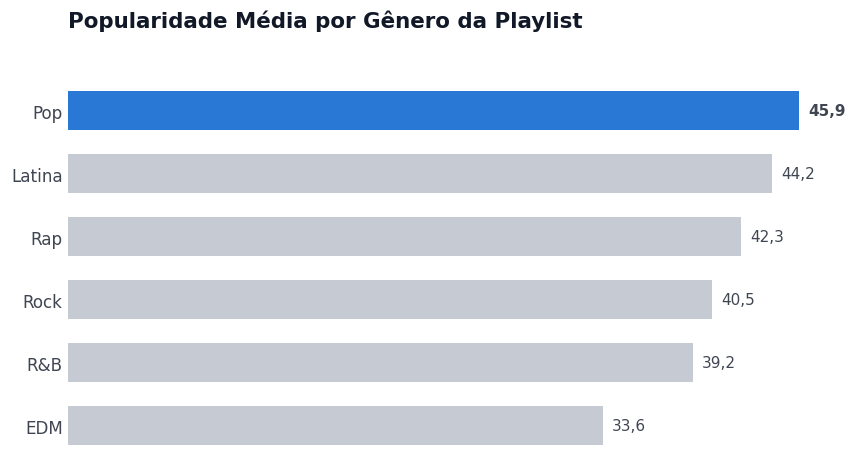

In [51]:
g1 = (musicas.drop_duplicates(subset=["id_musica", "genero_playlist"])
             .groupby("genero_playlist")["popularidade_musica"].mean()
             .sort_values())

fig, ax = plt.subplots(figsize=(9, 4.6))
cores = [COR_MUSICA if g == g1.idxmax() else COR_CINZA for g in g1.index]
ax.barh(g1.index, g1.values, color=cores, height=0.62)
for y, v in enumerate(g1.values):
    ax.text(v + 0.6, y, br(v), va="center", color=COR_TEXTO,
            fontweight="bold" if y == len(g1) - 1 else "normal")

titulos(ax, "Popularidade Média por Gênero da Playlist", "")
ax.xaxis.set_visible(False)
ax.spines[["bottom", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=11)
salvar(fig, "01_popularidade_por_genero_musical")
plt.show()

**Conclusão:** músicas de playlists de Pop têm popularidade média de 45,9, mais de 12 pontos acima das de EDM (33,6). Pop, Latina e Rap formam o grupo de cima.

## 2. A popularidade muda conforme o ano de lançamento?

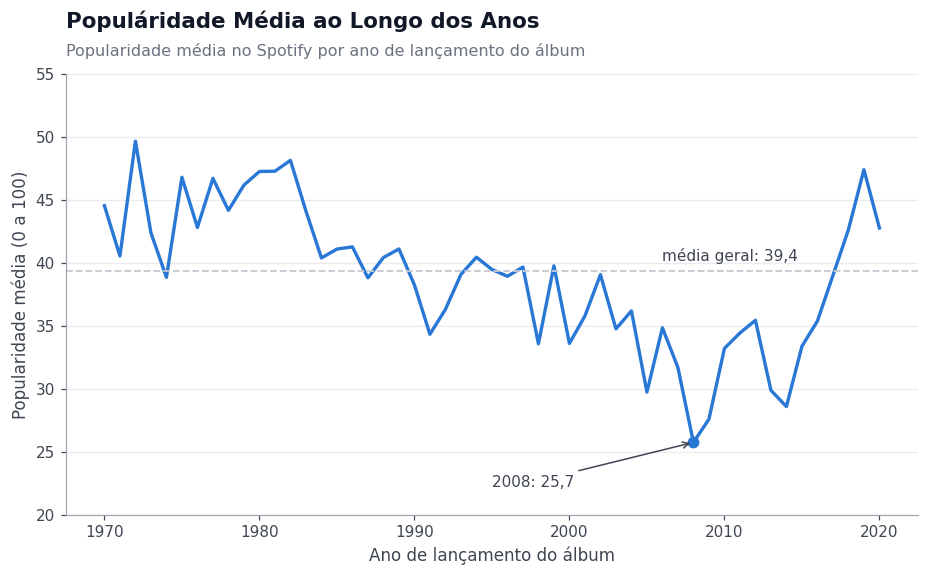

In [52]:
g2 = (musicas_unicas[musicas_unicas["ano_lancamento"] >= 1970]
      .groupby("ano_lancamento")["popularidade_musica"].agg(["mean", "count"]))
g2 = g2[g2["count"] >= 20]   # anos com menos de 20 músicas geram médias instáveis
media_geral = musicas_unicas["popularidade_musica"].mean()

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(g2.index, g2["mean"], color=COR_MUSICA, linewidth=2.2)
ax.axhline(media_geral, color=COR_CINZA, linestyle="--", linewidth=1.2)
ax.text(2006, media_geral + 0.8, f"média geral: {br(media_geral)}", color=COR_TEXTO)

vale = g2["mean"].idxmin()
ax.scatter([vale], [g2.loc[vale, "mean"]], color=COR_MUSICA, s=45, zorder=3)
ax.annotate(f"{vale}: {br(g2.loc[vale, 'mean'])}", xy=(vale, g2.loc[vale, "mean"]),
            xytext=(vale - 13, g2.loc[vale, "mean"] - 3.5),
            arrowprops=dict(arrowstyle="->", color=COR_TEXTO), color=COR_TEXTO)

titulos(ax, "Populáridade Média ao Longo dos Anos",
        f"Popularidade média no Spotify por ano de lançamento do álbum")
ax.set_xlabel("Ano de lançamento do álbum")
ax.set_ylabel("Popularidade média (0 a 100)")
ax.set_ylim(20, 55)
ax.grid(axis="y", alpha=0.25)
salvar(fig, "02_popularidade_por_ano_lancamento")
plt.show()

**Conclusão:** a curva tem forma de "U". Músicas dos anos 70 e as mais recentes ficam acima da média geral, enquanto as dos anos 2000 ficam bem abaixo. Só entram anos com pelo menos 20 músicas.

## 3. Características do áudio têm relação com a popularidade? (seaborn)

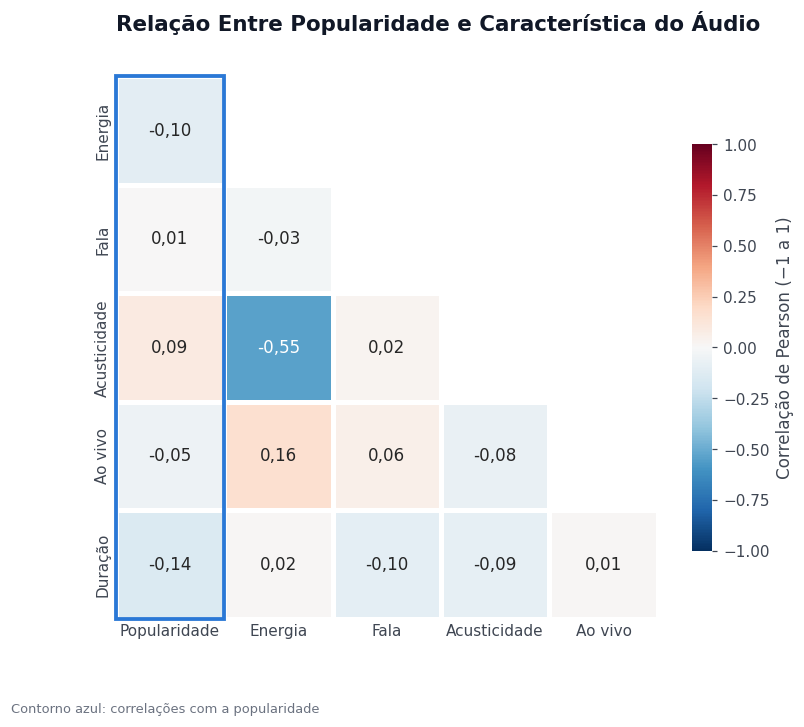

In [53]:
nomes = {"popularidade_musica": "Popularidade", "energia": "Energia", "fala": "Fala",
         "acusticidade": "Acusticidade", "prob_aovivo": "Ao vivo", "duracao_min": "Duração"}
corr = musicas_unicas[list(nomes)].rename(columns=nomes).corr().iloc[1:, :-1]
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6.4))
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", annot_kws={"size": 11},
            cmap="RdBu_r", vmin=-1, vmax=1, center=0, linewidths=2, linecolor="white",
            square=True, cbar_kws={"label": "Correlação de Pearson (−1 a 1)", "shrink": 0.75}, ax=ax)
for t in ax.texts:                                   # vírgula decimal nos rótulos
    t.set_text(t.get_text().replace(".", ","))
ax.add_patch(plt.Rectangle((0, 0), 1, 5, fill=False, edgecolor=COR_MUSICA, linewidth=2.5, clip_on=False))

titulos(ax, "Relação Entre Popularidade e Característica do Áudio",
        f"")
ax.tick_params(length=0)
fonte(fig, "Contorno azul: correlações com a popularidade")
salvar(fig, "03_correlacao_audio_popularidade")
plt.show()

**Conclusão:** todas as correlações com a popularidade ficam perto de zero (entre −0,14 e 0,09). A relação mais forte do mapa não envolve popularidade: músicas com mais **energia** tendem a ser menos **acústicas**.

## 4. As músicas ficaram mais curtas ao longo das décadas? (seaborn)

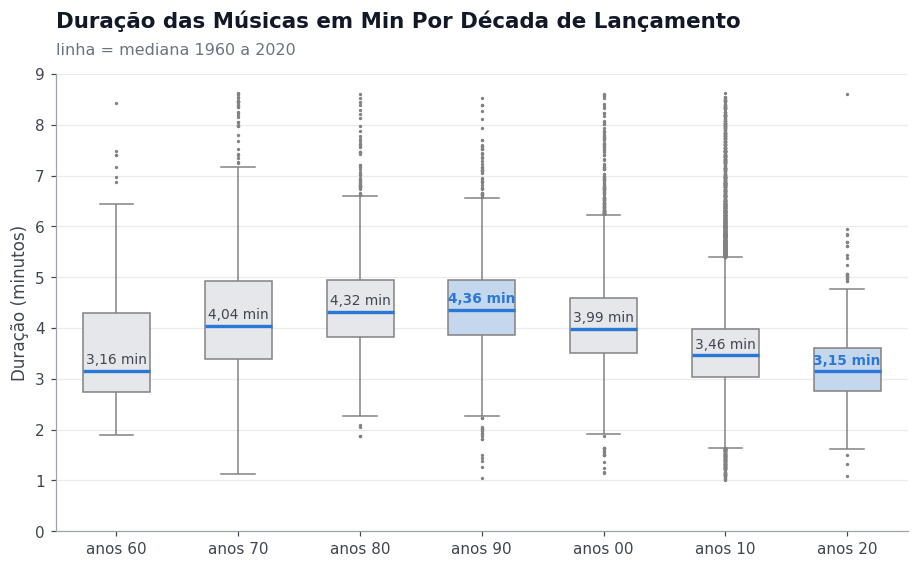

In [54]:
g4 = musicas_unicas[musicas_unicas["decada"] >= 1960].copy()   # anos 50 têm só 3 músicas
g4["decada_txt"] = "anos " + (g4["decada"] % 100).astype(str).str.zfill(2)
ordem = [f"anos {d % 100:02d}" for d in sorted(g4["decada"].unique())]
medianas = g4.groupby("decada_txt")["duracao_min"].median()
destaque = [medianas.idxmax(), ordem[-1]]

fig, ax = plt.subplots(figsize=(10, 5.4))
sns.boxplot(data=g4, x="decada_txt", y="duracao_min", order=ordem, hue="decada_txt",
            palette={d: (COR_MUSICA_CLARA if d in destaque else "#E5E7EB") for d in ordem},
            legend=False, width=0.55, fliersize=1.2, linewidth=1, ax=ax,
            medianprops=dict(color=COR_MUSICA, linewidth=2.2))
for i, d in enumerate(ordem):
    ax.text(i, medianas[d] + 0.14, f"{br(medianas[d], 2)} min", ha="center", fontsize=9,
            color=COR_MUSICA if d in destaque else COR_TEXTO,
            fontweight="bold" if d in destaque else "normal")

titulos(ax, "Duração das Músicas em Min Por Década de Lançamento",
        "linha = mediana 1960 a 2020")
ax.set_xlabel("")
ax.set_ylabel("Duração (minutos)")
ax.set_ylim(0, 9)
ax.grid(axis="y", alpha=0.25)
salvar(fig, "04_duracao_por_decada")
plt.show()

**Conclusão:** a duração mediana subiu até os anos 80 e 90 (cerca de 4,3 min) e caiu para cerca de 3,1 min nos anos 2020. A caixa também ficou mais estreita: as músicas recentes têm durações mais parecidas entre si.

## 5. Quais gêneros de filme têm as maiores notas médias?

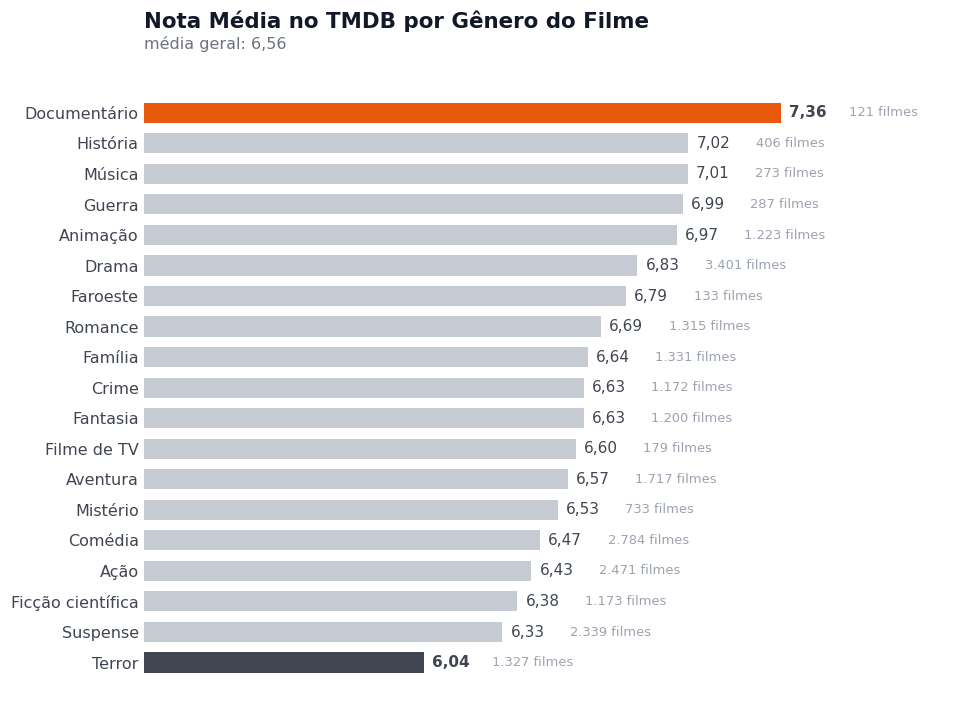

In [55]:
g5 = (filmes_generos[filmes_generos["nota_confiavel"]]
      .groupby("genero")["nota_media"].agg(["mean", "count"])
      .sort_values("mean"))
g5.index = g5.index.map(GENEROS_FILME)
media_conf = conf["nota_media"].mean()

fig, ax = plt.subplots(figsize=(9.5, 7.4))
cores = [COR_CINZA] * len(g5)
cores[-1] = COR_FILME          # maior nota
cores[0] = COR_TEXTO           # menor nota
ax.barh(g5.index, g5["mean"] - 5, left=5, color=cores, height=0.66)
for y, (v, n) in enumerate(zip(g5["mean"], g5["count"])):
    destaque = y in (0, len(g5) - 1)
    ax.text(v + 0.03, y, f"{br(v, 2)}", va="center", color=COR_TEXTO,
            fontweight="bold" if destaque else "normal")
    ax.text(v + 0.25, y, f"{br(n, 0)} filmes", va="center", color="#9CA3AF", fontsize=8.5)

titulos(ax, "Nota Média no TMDB por Gênero do Filme",
        f"média geral: {br(media_conf, 2)}")
ax.set_xlim(5, 8)
ax.xaxis.set_visible(False)
ax.spines[["bottom", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=10.5)
salvar(fig, "05_nota_por_genero_filme")
plt.show()

**Conclusão:** Documentário (7,36) lidera e Terror (6,04) fecha a lista. Gêneros de "entretenimento" como Ação, Suspense e Ficção científica ficam abaixo da média. O eixo começa em 5,5 para mostrar as diferenças, e por isso o número de cada barra está escrito ao lado.

## 6.  Quantidade de filmes e nota média por década

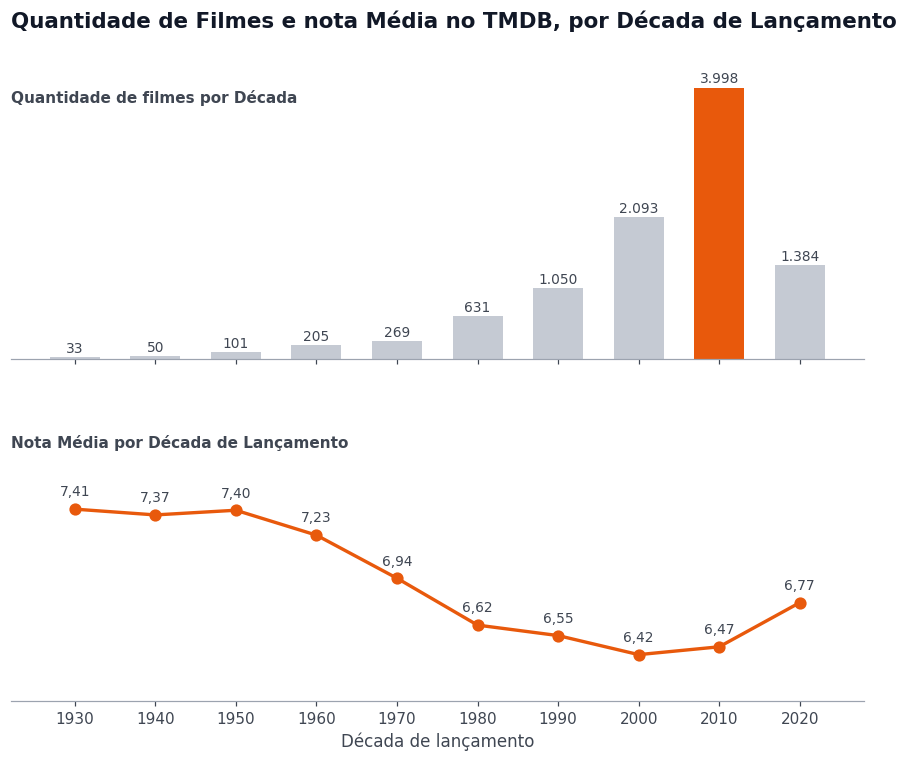

In [56]:
g6 = filmes[filmes["decada"] >= 1930].groupby("decada").agg(qtd=("titulo", "count"))
g6["nota"] = conf[conf["decada"] >= 1930].groupby("decada")["nota_media"].mean()
rotulos = [f"{d}" for d in g6.index]
maior = g6["qtd"].idxmax()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7.4), sharex=True,
                               gridspec_kw={"height_ratios": [1.15, 1], "hspace": 0.35})
ax1.bar(rotulos, g6["qtd"], width=0.62,
        color=[COR_FILME if d == maior else COR_CINZA for d in g6.index])
for i, v in enumerate(g6["qtd"]):
    ax1.text(i, v + 70, br(v, 0), ha="center", fontsize=9, color=COR_TEXTO)
ax1.yaxis.set_visible(False)
ax1.spines["left"].set_visible(False)
ax1.text(0, 0.9, "Quantidade de filmes por Década", transform=ax1.transAxes, color=COR_TEXTO, fontweight="bold")

ax2.plot(rotulos, g6["nota"], color=COR_FILME, marker="o", markersize=7, linewidth=2.2)
for i, v in enumerate(g6["nota"]):
    ax2.text(i, v + 0.09, br(v, 2), ha="center", fontsize=9, color=COR_TEXTO)
ax2.set_ylim(6.1, 7.8)
ax2.yaxis.set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.text(0, 1.02, "Nota Média por Década de Lançamento", transform=ax2.transAxes, color=COR_TEXTO, fontweight="bold")
ax2.set_xlabel("Década de lançamento")

titulos(ax1, "Quantidade de Filmes e nota Média no TMDB, por Década de Lançamento",
        "")
salvar(fig, "06_filmes_e_nota_por_decada")
plt.show()

**Conclusão:** a quantidade de filmes cresce década a década (3.998 nos anos 2010), enquanto a nota média cai de 7,4 nos anos 30 a 50 para 6,4 nos anos 2000. Isso indica um viés de sobrevivência: dos filmes antigos, só os clássicos continuam populares. Os dois painéis evitam um gráfico com dois eixos verticais.

## 7. Filmes com mais votos têm notas mais altas? (seaborn)

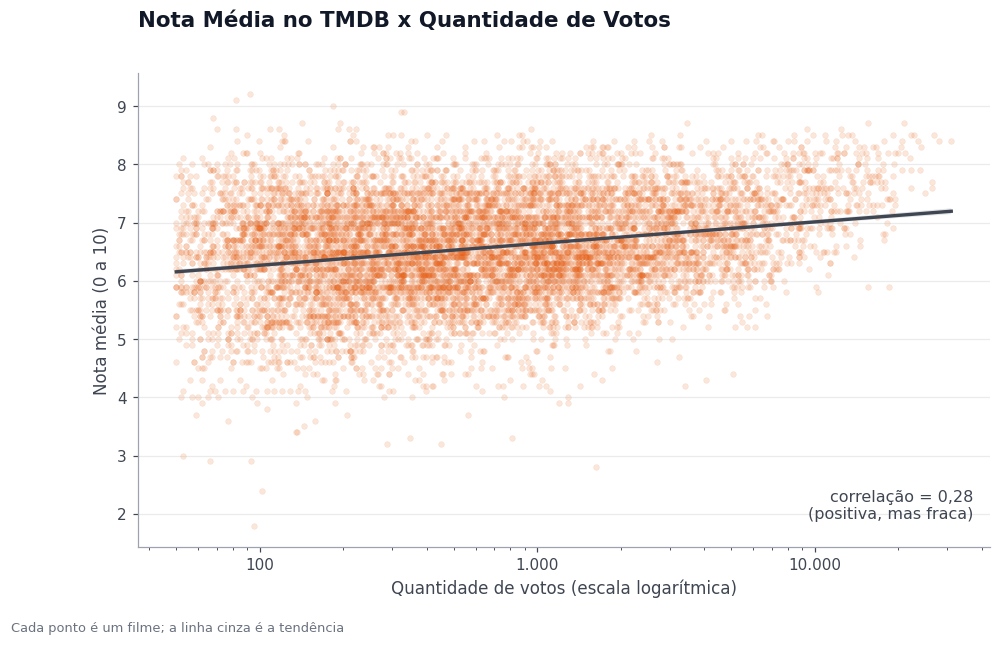

In [57]:
r = np.corrcoef(conf["qtd_votos"], conf["nota_media"])[0, 1]

fig, ax = plt.subplots(figsize=(10, 5.6))
sns.scatterplot(data=conf, x="qtd_votos", y="nota_media", color=COR_FILME, alpha=0.15,
                s=14, edgecolor=None, ax=ax)
sns.regplot(data=conf, x="qtd_votos", y="nota_media", logx=True, scatter=False,
            color=COR_TEXTO, line_kws={"linewidth": 2.2}, ax=ax)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: br(x, 0)))
ax.text(0.98, 0.06, f"correlação = {br(r, 2)}\n(positiva, mas fraca)", transform=ax.transAxes,
        ha="right", color=COR_TEXTO, fontsize=10.5)

titulos(ax, "Nota Média no TMDB x Quantidade de Votos",
        f"")
ax.set_xlabel("Quantidade de votos (escala logarítmica)")
ax.set_ylabel("Nota média (0 a 10)")
ax.grid(axis="y", alpha=0.25)
fonte(fig,"Cada ponto é um filme; a linha cinza é a tendência")
salvar(fig, "07_votos_x_nota")
plt.show()

**Conclusão:** a tendência é positiva, mas fraca (correlação de 0,28). Os 25% de filmes mais votados têm nota média de 6,89, contra 6,37 dos 25% menos votados. Há muitos filmes com nota alta e poucos votos, por isso os votos sozinhos não preveem a nota.

## 8. Quais idiomas originais aparecem mais e como são avaliados?

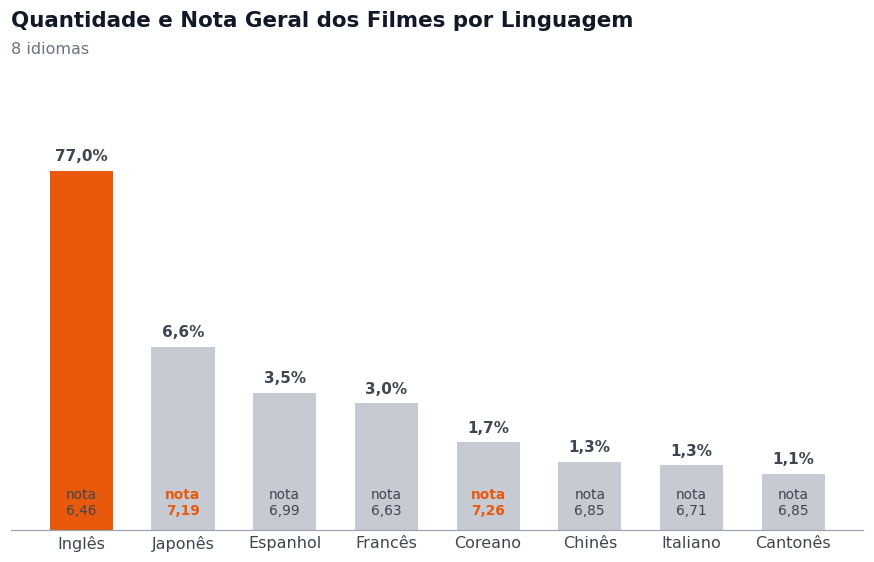

In [58]:
g8 = filmes.groupby("idioma").agg(qtd=("titulo", "count")).sort_values("qtd", ascending=False)
g8 = g8.drop(index="Outros", errors="ignore").head(8)
g8["nota"] = conf.groupby("idioma")["nota_media"].mean()
g8["pct"] = 100 * g8["qtd"] / len(filmes)
top_nota = g8["nota"].nlargest(2).index

fig, ax = plt.subplots(figsize=(10, 5.4))
ax.bar(g8.index, g8["qtd"], width=0.62,
       color=[COR_FILME if i == "Inglês" else COR_CINZA for i in g8.index])
ax.set_yscale("log")
for i, (idioma, q, p, n) in enumerate(zip(g8.index, g8["qtd"], g8["pct"], g8["nota"])):
    ax.text(i, q * 1.15, f"{br(p)}%", ha="center", color=COR_TEXTO, fontweight="bold", fontsize=10)
    ax.text(i, 62, f"nota\n{br(n, 2)}", ha="center", fontsize=9,
            color=COR_FILME if idioma in top_nota else COR_TEXTO,
            fontweight="bold" if idioma in top_nota else "normal")
ax.set_ylim(50, 30000)
ax.yaxis.set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", length=0, labelsize=10.5)

titulos(ax, "Quantidade e Nota Geral dos Filmes por Linguagem",
        f"8 idiomas")
salvar(fig, "08_idiomas_originais")
plt.show()

**Conclusão:** 77% dos filmes são em inglês, mas eles têm a menor nota média entre os principais idiomas (6,46). Coreano (7,26) e japonês (7,19) lideram. A escala logarítmica permite ver os idiomas menores ao lado do inglês.

**Conclusão:** os dois temas crescem ao longo do tempo, o que explica a correlação de 0,70 entre eles. O motivo é a forma como os dados foram coletados (playlists e filmes populares hoje), e não uma relação entre música e cinema.

## Pergunta 8 (mapa) · Onde se falam os idiomas dos filmes populares? (cartopy)

Os datasets não têm o país de produção dos filmes, só o **idioma original**. Por isso, o mapa colore cada país pelo número de filmes **no seu idioma principal**. Por exemplo, Brasil e Portugal recebem os 37 filmes em português.

Isso **não é** o país de produção. Um filme em inglês pode ser americano, britânico ou australiano, e todos esses países recebem o mesmo valor.

In [59]:
# idioma principal de cada país (nomes iguais aos da coluna ADMIN do Natural Earth)
PAISES_POR_IDIOMA = {
    "en": ["United States of America", "United Kingdom", "Canada", "Australia", "New Zealand", "Ireland"],
    "ja": ["Japan"],
    "es": ["Spain", "Mexico", "Argentina", "Colombia", "Chile", "Peru", "Venezuela", "Ecuador",
           "Bolivia", "Paraguay", "Uruguay", "Cuba", "Guatemala", "Honduras", "Nicaragua",
           "El Salvador", "Costa Rica", "Panama", "Dominican Republic"],
    "fr": ["France"], "ko": ["South Korea"], "zh": ["China", "Taiwan"], "cn": ["China"],
    "it": ["Italy"], "ru": ["Russia"], "de": ["Germany", "Austria"],
    "pt": ["Brazil", "Portugal", "Angola", "Mozambique"],
    "hi": ["India"], "te": ["India"], "ta": ["India"], "ml": ["India"],
    "da": ["Denmark"], "no": ["Norway"], "nb": ["Norway"], "sv": ["Sweden"], "nl": ["Netherlands"],
    "th": ["Thailand"], "pl": ["Poland"], "tr": ["Turkey"], "id": ["Indonesia"], "tl": ["Philippines"],
    "fi": ["Finland"], "sr": ["Republic of Serbia"], "el": ["Greece"], "cs": ["Czechia"],
    "fa": ["Iran"], "hu": ["Hungary"], "is": ["Iceland"], "ro": ["Romania"], "uk": ["Ukraine"],
    "he": ["Israel"], "ms": ["Malaysia"], "lv": ["Latvia"], "et": ["Estonia"], "bn": ["Bangladesh"],
}

qtd_idioma = filmes["idioma_original"].value_counts()
dados = {}
for idioma, paises in PAISES_POR_IDIOMA.items():
    for p in paises:
        dados[p] = dados.get(p, 0) + int(qtd_idioma.get(idioma, 0))

shp = shpreader.natural_earth("110m", "cultural", "admin_0_countries")
registros = list(shpreader.Reader(shp).records())
nomes_mapa = {r.attributes["ADMIN"] for r in registros}
print("Países sem correspondência no mapa:", sorted(set(dados) - nomes_mapa))   # conferência, como no merge
print("Países coloridos:", sum(v > 0 for v in dados.values()))

Países sem correspondência no mapa: []
Países coloridos: 62


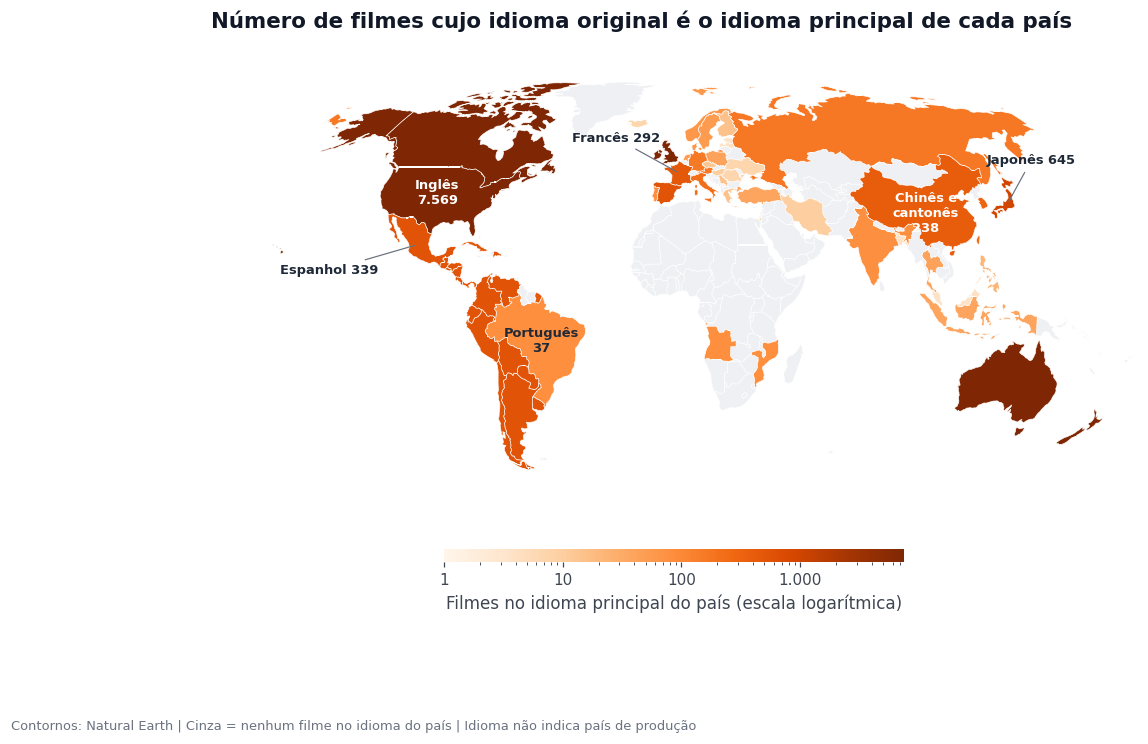

In [60]:
norma = LogNorm(vmin=1, vmax=max(dados.values()))
cmap = plt.cm.Oranges

fig = plt.figure(figsize=(12, 6.6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
for r in registros:
    nome = r.attributes["ADMIN"]
    if nome == "Antarctica":
        continue
    v = dados.get(nome, 0)
    cor = cmap(0.15 + 0.85 * norma(v)) if v > 0 else "#EEF0F3"
    ax.add_geometries([r.geometry], ccrs.PlateCarree(), facecolor=cor,
                      edgecolor="white", linewidth=0.4)
ax.spines["geo"].set_visible(False)

# rótulos: texto branco sobre as cores escuras
rotulos_mapa = [(-100, 40, "Inglês\n7.569", "white"),
                (-52, -11, "Português\n37", "#1F2937"), (103, 33, "Chinês e\ncantonês\n238", "white")]
for lon, lat, txt, cor in rotulos_mapa:
    ax.text(lon, lat, txt, transform=ccrs.PlateCarree(), ha="center", va="center",
            fontsize=8.5, color=cor, fontweight="bold")
# países pequenos: rótulo fora, com linha
for lon, lat, xt, yt, txt in [(2.5, 46.5, -28, 58, "Francês 292"), (138, 36, 160, 50, "Japonês 645"), (-102, 22, -135, 12, "Espanhol 339")]:
    ax.annotate(txt, xy=(lon, lat), xytext=(xt, yt), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax), ha="center", fontsize=8.5,
                fontweight="bold", color="#1F2937", arrowprops=dict(arrowstyle="-", color="#6B7280", lw=0.8))

sm = plt.cm.ScalarMappable(norm=norma, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.45, pad=0.01, aspect=35)
cbar.set_label("Filmes no idioma principal do país (escala logarítmica)", color=COR_TEXTO)
cbar.ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: br(x, 0)))
cbar.outline.set_visible(False)

titulos(ax, "Número de filmes cujo idioma original é o idioma principal de cada país",
        f"")
fonte(fig,"Contornos: Natural Earth | Cinza = nenhum filme no idioma do país | Idioma não indica país de produção")
salvar(fig, "09_mapa_idiomas_filmes")
plt.show()

**Conclusão:** os países de língua inglesa concentram de longe a maior cor, com 7.569 filmes. Fora deles, só Japão (645), países de língua espanhola (339), França (292) e China (238) aparecem com destaque. A África, o Oriente Médio e boa parte da Ásia ficam praticamente sem filmes no seu idioma.

## Lançamentos por ano nos dois temas

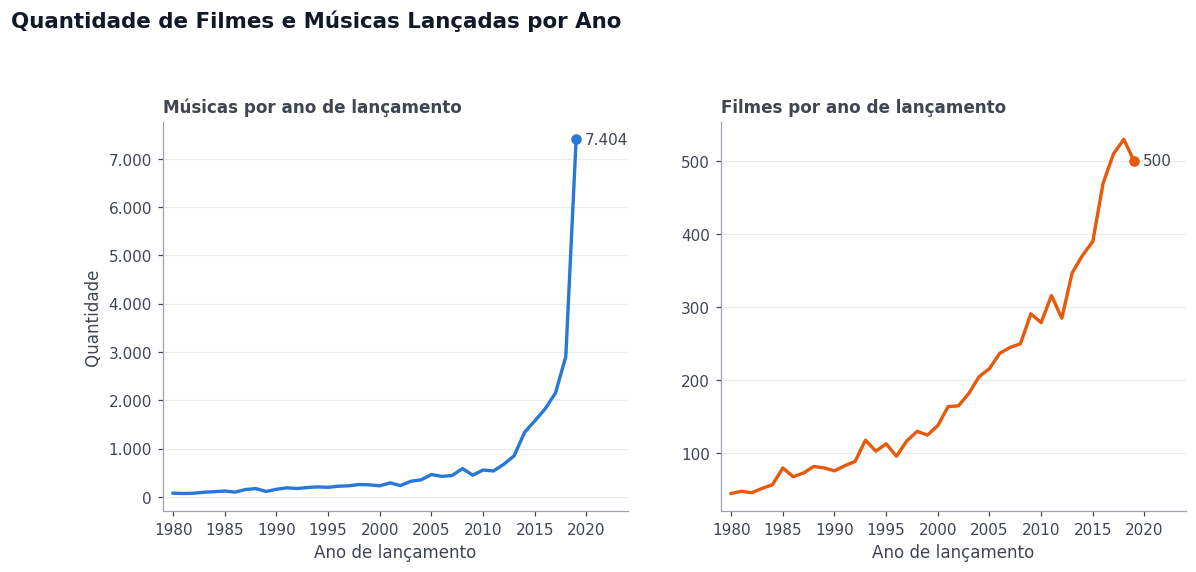

In [63]:
b = por_ano[por_ano["ano"].between(1980, 2019)]   # 2020 está incompleto no dataset de músicas
r_b = np.corrcoef(b["qtd_musicas"], b["qtd_filmes"])[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)
for ax, col, cor, nome in [(ax1, "qtd_musicas", COR_MUSICA, "Músicas"), (ax2, "qtd_filmes", COR_FILME, "Filmes")]:
    ax.plot(b["ano"], b[col], color=cor, linewidth=2.2)
    ultimo = b.iloc[-1]
    ax.scatter([ultimo["ano"]], [ultimo[col]], color=cor, s=35, zorder=3)
    ax.text(ultimo["ano"] + 0.8, ultimo[col], br(ultimo[col], 0), ha="left", va="center", color=COR_TEXTO)
    ax.set_xlim(1979, 2024)
    ax.set_title(f"{nome} por ano de lançamento", loc="left", fontsize=11, fontweight="bold", color=COR_TEXTO)
    ax.set_xlabel("Ano de lançamento")
    ax.grid(axis="y", alpha=0.25)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: br(x, 0)))
ax1.set_ylabel("Quantidade")

fig.suptitle("Quantidade de Filmes e Músicas Lançadas por Ano", x=0.01, y=1.1, ha="left",
             fontsize=14, fontweight="bold", color="#111827")

salvar(fig, "10_bonus_lancamentos_por_ano")
plt.show()